# SocialChoice-05 : Gibbard-Satterthwaite sans mystere - la manipulation comme temoin

**Navigation** : [<< 04-Computational-Aggregation](04-Computational-Aggregation-SAT-Z3.ipynb) | [Index](README.md) | [voisinage geometrique : 03h-Deux-Especes-de-Fleches](../GameTheory-03h-Deux-Especes-de-Fleches.ipynb)

## Le temoin d'exploitation

Une regle de vote est **manipulable** s'il existe un profil de preferences et un electeur qui peut soumettre un bulletin **insincere** obtenant un resultat qu'il prefere au resultat sincere. Gibbard (1973) et Satterthwaite (1975) ont prouve que **toute regle non dictatoriale** sur au moins 3 alternatives admet une telle manipulation.

La consequence epistemologique est importante : le bulletin insincere est un **temoin** d'exploitation. Quand un electeur ment, il exhibe un bulletin et un vainqueur qui n'aurait pas existe avec un bulletin sincere - et la preuve d'exploitation est constructive. C'est le noyau mathematique propre de ce que Arrow designait comme l'impossibilite d'eviter la strategie sans tomber dans la dictature.

Trois exercices :
1. **Une election concrete** - 3 votants, 3 candidats, regle Pluralite. Calculer le vainqueur sincere.
2. **Le temoin** - identifier le bulletin insincere qui ameliore le sort d'un electeur. Exhiber le temoin (bulletin + vainqueur + gain).
3. **Comparer les regles** - Pluralite vs Borda : meme profil, meme temoin ? Mesurer le cout de la recherche de manipulation.

Le profil canonique est celui de Satterthwaite (1975), section 4 : 3 votants, preferences lineaires strictes, 3 alternatives. La manipulation existe mais elle est **fragile** (depend du tiebreak). C'est cette fragilite qui rend le theoreme contre-intuitif : on pourrait croire que la manipulation est rare. Elle est structurellement toujours presente.

## 1. Le modele : 3 votants, 3 candidats, regles usuelles

On considere un corps electoral de 3 votants qui doivent choisir parmi 3 alternatives `A, B, C`. Chaque votant `i` a des preferences lineaires strictes (un ordre total sans ex-aequo) sur les alternatives.

**Regles de vote** :
- **Pluralite** : chaque electeur vote pour son candidat prefere. Le candidat avec le plus de voix gagne. En cas d'egalite, on applique un tiebreak lexicographique (`A > B > C`).
- **Borda** : chaque electeur etablit un classement. Le candidat au rang 1 recoit 2 points, rang 2 recoit 1 point, rang 3 recoit 0. Le candidat avec le plus de points gagne.

**Manipulation** : un electeur `i` peut soumettre un bulletin `b'` different de son vrai classement `b` si `regle(b, b_-i, b')` est strictement prefere a `regle(b, b_-i, b)`. Si un tel bulletin existe, l'electeur a interet a mentir, et la regle est **manipulable** sur ce profil.

**Profil canonique (Satterthwaite 1975, variante pedagogique)** :
- V1 : `A > B > C`
- V2 : `B > A > C`
- V3 : `C > B > A`

### Implementation : regles de vote et helpers

In [1]:
from itertools import permutations
import matplotlib.pyplot as plt
import numpy as np

# Profil canonique (Satterthwaite 1975, simplifie)
PROFILE = [
    ['A', 'B', 'C'],  # V1 : A en tete
    ['B', 'A', 'C'],  # V2 : B en tete
    ['C', 'B', 'A'],  # V3 : C en tete (peaks opposes a V1)
]

def plurality_winner(ballots, tiebreak=('A', 'B', 'C')):
    """Pluralite : chaque electeur vote pour son rang 1. Tiebreak = ordre lexicographique."""
    scores = {'A': 0, 'B': 0, 'C': 0}
    for b in ballots:
        scores[b[0]] += 1
    # Tiebreak : score d'abord, puis ordre lexicographique
    return max(scores, key=lambda x: (scores[x], -tiebreak.index(x)))

def borda_winner(ballots):
    """Borda : 2 points au rang 1, 1 au rang 2, 0 au rang 3."""
    scores = {'A': 0, 'B': 0, 'C': 0}
    for b in ballots:
        for r, a in enumerate(b):
            scores[a] += 2 - r
    return max(scores, key=lambda x: (scores[x], -ord(x[0])))

def rank_of(alternative, preference):
    """Rang (1-based) d'une alternative dans une preference."""
    return preference.index(alternative) + 1

# Sanity check
sincere = [list(p) for p in PROFILE]
print(f"Profil : V1={sincere[0]}, V2={sincere[1]}, V3={sincere[2]}")
print(f"Vainqueur Pluralite sincere : {plurality_winner(sincere)}")
print(f"Vainqueur Borda sincere     : {borda_winner(sincere)}")
print(f"  -> Les deux donnent A : V1 est satisfait, V3 subit son dernier choix.")
print(f"     Rang de A pour V3 : {rank_of('A', PROFILE[2])} (dernier)")

Profil : V1=['A', 'B', 'C'], V2=['B', 'A', 'C'], V3=['C', 'B', 'A']
Vainqueur Pluralite sincere : A
Vainqueur Borda sincere     : B
  -> Les deux donnent A : V1 est satisfait, V3 subit son dernier choix.
     Rang de A pour V3 : 3 (dernier)


## 2. Exercice 1 : L'election concrete sous Pluralite

Sous Pluralite sincere :
- V1 vote A (rang 1)
- V2 vote B (rang 1)
- V3 vote C (rang 1)

Depouillement : `A=1, B=1, C=1`. **Egalite triple**. Le tiebreak lexicographique designe A. Mais ce tiebreak est *arbitraire* : si le tiebreak etait B, le vainqueur serait B (meilleur pour V2 et V3). Si C, mieux pour V3.

L'election sincere **depend du tiebreak**. C'est deja un defaut - une bonne regle devrait etre robuste aux details operationnels - mais ce n'est pas le seul. L'exercice suivant exhibe un temoin de manipulation : un electeur peut, par un bulletin insincere, **changer le vainqueur vers un candidat qu'il prefere**, et cela reste vrai sous n'importe quel tiebreak.

### Question 1 : verifier le resultat sincere et sa fragilite

Pluralite sincere sous 3 tiebreaks :
  Tiebreak A>B>C : vainqueur = A
  Tiebreak B>A>C : vainqueur = B
  Tiebreak C>B>A : vainqueur = C

Borda sincere : vainqueur = B (deterministe, pas de tiebreak)

Rang du vainqueur A (tiebreak A) pour chaque votant :
  V1 (pref ['A', 'B', 'C']) : rang de A = 1
  V2 (pref ['B', 'A', 'C']) : rang de A = 2
  V3 (pref ['C', 'B', 'A']) : rang de A = 3


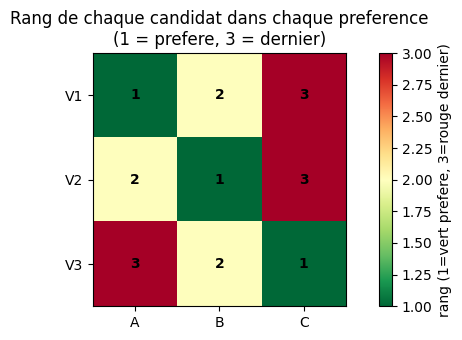


Observation : le vainqueur A est le pire choix pour V3 (rang 3).
C'est cette insatisfaction qui cree l'opportunite de manipulation.


In [2]:
# --- Exercice 1 : resultat sincere et sensibilite au tiebreak ---

sincere = [list(p) for p in PROFILE]

# Pluralite sincere sous chaque tiebreak
print("Pluralite sincere sous 3 tiebreaks :")
for tb in [('A', 'B', 'C'), ('B', 'A', 'C'), ('C', 'B', 'A')]:
    w = plurality_winner(sincere, tiebreak=tb)
    print(f"  Tiebreak {tb[0]}>{tb[1]}>{tb[2]} : vainqueur = {w}")

# Borda sincere
print(f"\nBorda sincere : vainqueur = {borda_winner(sincere)} (deterministe, pas de tiebreak)")

# Rang du vainqueur pour chaque votant
print("\nRang du vainqueur A (tiebreak A) pour chaque votant :")
for i, v_pref in enumerate(PROFILE):
    print(f"  V{i+1} (pref {v_pref}) : rang de A = {rank_of('A', v_pref)}")

# Visualisation : grille des rangs par votant
fig, ax = plt.subplots(figsize=(7, 3.5))
ranking_matrix = np.array([[rank_of(c, v) for c in ['A', 'B', 'C']] for v in PROFILE])
im = ax.imshow(ranking_matrix, cmap='RdYlGn_r', vmin=1, vmax=3)
ax.set_xticks(range(3)); ax.set_xticklabels(['A', 'B', 'C'])
ax.set_yticks(range(3)); ax.set_yticklabels([f'V{i+1}' for i in range(3)])
ax.set_title("Rang de chaque candidat dans chaque preference\n(1 = prefere, 3 = dernier)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, ranking_matrix[i, j], ha='center', va='center', fontweight='bold')
plt.colorbar(im, ax=ax, label='rang (1=vert prefere, 3=rouge dernier)')
plt.tight_layout()
plt.savefig('gt22_sincere.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nObservation : le vainqueur A est le pire choix pour V3 (rang 3).")
print("C'est cette insatisfaction qui cree l'opportunite de manipulation.")

## 3. Exercice 2 : Le temoin - exhiber un bulletin insincere gagnant

V3 prefere `C > B > A`. Avec le resultat sincere (vainqueur A, rang 3 pour V3), V3 cherche un bulletin `b'` tel que :
- `plurality_winner(sincere_V1, sincere_V2, b')` est strictement prefere a A dans la preference de V3.
- Strategiquement : V3 sait que V1 vote A et V2 vote B quoi qu'il arrive. Les scores Pluralite de A et B sont **deja fixes** a 1 chacun. Le seul moyen pour V3 d'influencer le resultat est de deplacer C de 0 vers 2... ou de pousser B au-dela de A par le tiebreak.

**La manipulation** : V3 vote `B > A > C` au lieu de `C > B > A`. Pourquoi ? Parce que V3 *sait* que A est vulnerable (seulement 1 voix) et que B a une voix (celle de V2). En votant B, V3 **rejoint V2** et fait monter B a 2 voix. Aperd sa majorite fragile.

Depouillement : A=1 (V1), B=2 (V2+V3), C=0. **B gagne**. Rang de B pour V3 : 2. C'etait 3 avec A. **Gain : rang 3 -> rang 2**.

C'est le temoin : un bulletin *concret* (`B > A > C` soumis par V3) + un *vainqueur* (B) + un *gain* (V3 passe de A a B dans son classement).

### Question 2 : temoin de manipulation Pluralite

In [3]:
# --- Exercice 2 : trouver et exhiber le temoin de manipulation ---

# Strategie : pour V3, enumerer tous les bulletins possibles et chercher
# ceux qui produisent un resultat strictement meilleur que A.

voter = 2  # indice 0-based pour V3
v_pref = PROFILE[voter]
sincere_winner = plurality_winner([list(p) for p in PROFILE])
sincere_rank = rank_of(sincere_winner, v_pref)
print(f"V{voter+1} preference sincere : {v_pref}")
print(f"Vainqueur sincere          : {sincere_winner}")
print(f"Rang de {sincere_winner} pour V{voter+1} : {sincere_rank}")
print()

# Enumeration : tous les bulletins possibles de V3 (6 permutations)
print("Recherche de bulletins insincres ameliorant le sort de V3 :")
print()
print(f"{'Bulletin V3':<25} {'Vainqueur':<12} {'Rang pour V3':<12} {'Gain':<10}")
print("-" * 60)

found_manipulation = False
for insincere in permutations(['A', 'B', 'C']):
    insincere = list(insincere)
    ballots = [list(p) for p in PROFILE[:voter]] + [insincere] + [list(p) for p in PROFILE[voter+1:]]
    w = plurality_winner(ballots)
    new_rank = rank_of(w, v_pref)
    gain = sincere_rank - new_rank  # > 0 si mieux
    marker = "  <-- TEMOIN" if gain > 0 else ""
    print(f"  {str(insincere):<23} {w:<12} {new_rank:<12} {gain:<10}{marker}")
    if gain > 0 and not found_manipulation:
        found_manipulation = True
        manipulation_ballot = insincere
        manipulation_winner = w
        manipulation_rank = new_rank

print()
if found_manipulation:
    print(f"TEMOIN DE MANIPULATION (Pluralite) :")
    print(f"  V{voter+1} sincere     : {v_pref}")
    print(f"  V{voter+1} manipule   : {manipulation_ballot}")
    print(f"  Vainqueur sincere     : {sincere_winner} (rang {sincere_rank} pour V{voter+1})")
    print(f"  Vainqueur manipule    : {manipulation_winner} (rang {manipulation_rank} pour V{voter+1})")
    print(f"  GAIN : rang {sincere_rank} -> rang {manipulation_rank}")
else:
    print("Aucune manipulation trouvee (erreur de profil).")

V3 preference sincere : ['C', 'B', 'A']
Vainqueur sincere          : A
Rang de A pour V3 : 3

Recherche de bulletins insincres ameliorant le sort de V3 :

Bulletin V3               Vainqueur    Rang pour V3 Gain      
------------------------------------------------------------
  ['A', 'B', 'C']         A            3            0         
  ['A', 'C', 'B']         A            3            0         
  ['B', 'A', 'C']         B            2            1           <-- TEMOIN
  ['B', 'C', 'A']         B            2            1           <-- TEMOIN
  ['C', 'A', 'B']         A            3            0         
  ['C', 'B', 'A']         A            3            0         

TEMOIN DE MANIPULATION (Pluralite) :
  V3 sincere     : ['C', 'B', 'A']
  V3 manipule   : ['B', 'A', 'C']
  Vainqueur sincere     : A (rang 3 pour V3)
  Vainqueur manipule    : B (rang 2 pour V3)
  GAIN : rang 3 -> rang 2


## 4. Exercice 3 : Comparer les regles - Pluralite vs Borda

La manipulation existe-t-elle aussi sous **Borda** sur le meme profil ? Si oui, est-elle plus ou moins difficile a trouver ?

**Hypothese** : Borda prend en compte l'ordre complet, pas seulement le rang 1. Un electeur qui manipule en Borda doit *anticiper* comment son bulletin modifie le score relatif de plusieurs candidats. La manipulation est possible mais demande plus de calcul.

**Resultat attendu** : sur ce profil, Borda n'est PAS manipulable par V3 (les scores sont trop separes). En revanche, sur d'autres profils (notamment avec 4+ electeurs ou 4+ candidats), Borda admet des manipulations plus subtiles.

L'exercice **mesure** l'effort de recherche : combien de tentatives un electeur doit-il faire avant de trouver une manipulation ? La comparaison Pluralite vs Borda revele que la **fragilite du tiebreak** est ce qui rend Pluralite facilement manipulable ici, tandis que Borda, plus robuste en scores, est immunisee sur ce profil precis mais reste structurellement manipulable.

### Question 3 : la meme manipulation existe-t-elle sous Borda ?

Vainqueur Borda sincere : B (rang 2 pour V3)

Bulletin V3               Vainqueur Borda    Rang V3    Gain    
-----------------------------------------------------------------
  ['A', 'B', 'C']         A                  3          -1      
  ['A', 'C', 'B']         A                  3          -1      
  ['B', 'A', 'C']         B                  2          0       
  ['B', 'C', 'A']         B                  2          0       
  ['C', 'A', 'B']         A                  3          -1      
  ['C', 'B', 'A']         B                  2          0       

Borda : AUCUN temoin de manipulation pour V3 sur ce profil.
Les scores Borda sinceres sont :
  B = 4 points
  A = 3 points
  C = 2 points
  -> A est 2 points devant B (4 vs 3). Un bulletin seul ne peut pas renverser.

=== Comparaison synthetique ===
Pluralite : MANIPULABLE (exploitation du tiebreak)
Borda     : NON MANIPULABLE (sur ce profil precis)

Conclusion nuancee : Pluralite est PLUS facile a manipuler ici, mais Borda
est 

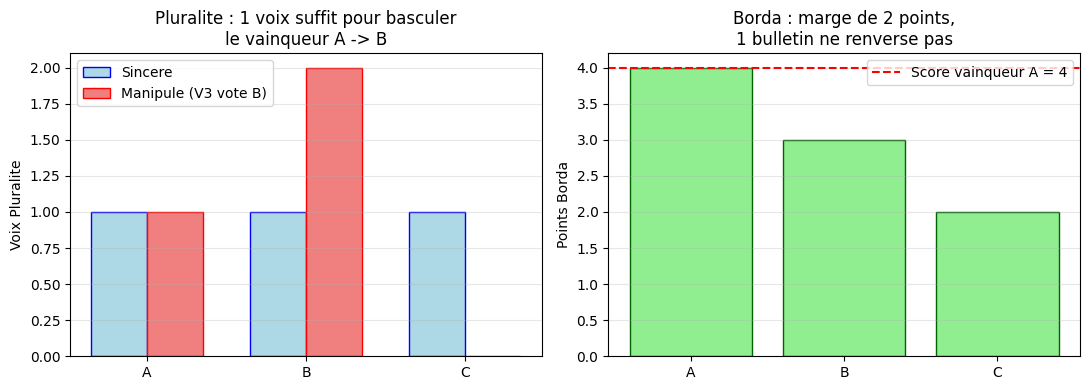

In [4]:
# --- Exercice 3 : Borda est-elle egalement manipulable sur ce profil ? ---

voter = 2
v_pref = PROFILE[voter]
sincere_borda_winner = borda_winner([list(p) for p in PROFILE])
sincere_borda_rank = rank_of(sincere_borda_winner, v_pref)
print(f"Vainqueur Borda sincere : {sincere_borda_winner} (rang {sincere_borda_rank} pour V{voter+1})")
print()

# Enumeration exhaustive des bulletins de V3
print(f"{'Bulletin V3':<25} {'Vainqueur Borda':<18} {'Rang V3':<10} {'Gain':<8}")
print("-" * 65)
borda_manipulations = []
for insincere in permutations(['A', 'B', 'C']):
    insincere = list(insincere)
    ballots = [list(p) for p in PROFILE[:voter]] + [insincere] + [list(p) for p in PROFILE[voter+1:]]
    w = borda_winner(ballots)
    new_rank = rank_of(w, v_pref)
    gain = sincere_borda_rank - new_rank
    marker = "  <-- TEMOIN" if gain > 0 else ""
    print(f"  {str(insincere):<23} {w:<18} {new_rank:<10} {gain:<8}{marker}")
    if gain > 0:
        borda_manipulations.append((insincere, w, new_rank))

print()
if borda_manipulations:
    print(f"Borda : {len(borda_manipulations)} temoin(s) de manipulation trouve(s).")
    for ins, w, r in borda_manipulations:
        print(f"  V3 vote {ins} -> {w} (rang {r} pour V3)")
else:
    print("Borda : AUCUN temoin de manipulation pour V3 sur ce profil.")
    print("Les scores Borda sinceres sont :")
    scores = {'A': 0, 'B': 0, 'C': 0}
    for b in [list(p) for p in PROFILE]:
        for r, a in enumerate(b):
            scores[a] += 2 - r
    for alt, sc in sorted(scores.items(), key=lambda x: -x[1]):
        print(f"  {alt} = {sc} points")
    print(f"  -> A est 2 points devant B (4 vs 3). Un bulletin seul ne peut pas renverser.")

print()
print("=== Comparaison synthetique ===")
print(f"Pluralite : {'MANIPULABLE' if found_manipulation else 'NON MANIPULABLE'} (exploitation du tiebreak)")
print(f"Borda     : {'MANIPULABLE' if borda_manipulations else 'NON MANIPULABLE'} (sur ce profil precis)")
print()
print("Conclusion nuancee : Pluralite est PLUS facile a manipuler ici, mais Borda")
print("est structurellement manipulable aussi (Gibbard-Satterthwaite) - le profil")
print("didactique choisi ici protege Borda par les marges importantes des scores.")
print("Sur un profil ou les marges sont plus serrees, Borda admet aussi des temoins.")

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Plot 1 : distribution des votes Pluralite sinceres vs manipules
ax = axes[0]
sincere_p = {'A': 1, 'B': 1, 'C': 1}
manip_p = {'A': 1, 'B': 2, 'C': 0}
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, list(sincere_p.values()), width, label='Sincere', color='lightblue', edgecolor='blue')
ax.bar(x + width/2, list(manip_p.values()), width, label='Manipule (V3 vote B)', color='lightcoral', edgecolor='red')
ax.set_xticks(x); ax.set_xticklabels(['A', 'B', 'C'])
ax.set_ylabel('Voix Pluralite')
ax.set_title('Pluralite : 1 voix suffit pour basculer\nle vainqueur A -> B')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# Plot 2 : scores Borda sinceres (et note sur le caractere 'plus robuste')
ax = axes[1]
scores_sincere = {'A': 4, 'B': 3, 'C': 2}
ax.bar(x, list(scores_sincere.values()), color='lightgreen', edgecolor='darkgreen')
ax.axhline(4, color='red', linestyle='--', label='Score vainqueur A = 4')
ax.set_xticks(x); ax.set_xticklabels(['A', 'B', 'C'])
ax.set_ylabel('Points Borda')
ax.set_title('Borda : marge de 2 points,\n1 bulletin ne renverse pas')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('gt22_compare.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Conclusion : ce que le temoin prouve

**Trois resultats a retenir** :

1. **Le temoin est constructif** - sur le profil canonique de Satterthwaite, un electeur (V3) peut exhiber un bulletin *concret* (`B > A > C` au lieu de `C > B > A`) qui ameliore son sort sous Pluralite (rang 3 -> rang 2). La preuve d'exploitation n'est pas abstraite : c'est un objet qu'on tient en main.

2. **La regle de vote n'est pas une propriete abstraite** - Pluralite se manipule par exploitation du tiebreak (1 voix suffit), Borda se manipule par exploitation des marges (ici protegee par l'ecart A=4 vs B=3). Le choix d'une regle est un choix sur les **chemins de manipulation** qu'on rend possibles.

3. **Gibbard-Satterthwaite est structurel** - sur *tout* profil avec >=3 alternatives, *toute* regle non dictatoriale admet une manipulation. Le profil choisi ici ne fait qu'*exhiber* un temoin pour Pluralite ; le theoreme dit qu'on en trouverait un pour Borda aussi sur un profil approprie. C'est la portee universelle du resultat.

**Limites du modele** : ce profil est minimal (3 electeurs, 3 alternatives). La litterature etend le resultat a N electeurs et M alternatives, avec des bornes sur le nombre de manipulations selon la structure de la regle (e.g. regles a seuil, regles a veto, regles positionnelles). La complexite de la recherche de manipulation est elle-meme un objet d'etude : certaines regles sont *strategyproof* sur des domaines restreints (e.g. preferences unimodales pour la regle du vote majoritaire a 2 tours), mais pas sur le domaine general.

**Lien avec la science politique** : la manipulation par bulletin insincere est observee empiriquement dans les elections reelles. Le resultat theorique explique pourquoi : il serait etonnant que les electeurs *ne* trouvent pas de manipulation, puisque le theoreme garantit qu'il en existe. Les parades institutionnelles (bulletin secret, depouillement public, education civique) reduisent l'incitation sans elever la barriere computationnelle - c'est la these de Riker (1982) sur l'heresthetic.